In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import re
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")


In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ GPU kullanılıyor")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("⚠️ GPU yok, CPU kullanılıyor")


✅ GPU kullanılıyor
GPU: NVIDIA L4


In [ ]:
df = pd.read_csv("articles_clean.csv")
df.head()


,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...


In [ ]:
df["combined_text"].iloc[0]


'i̇nsansız hava araçları için manyetik rezonans kuplaj ile şarj i̇stasyonu tasarımı i̇nsansız hava araçları (i̇ha) çeşitli alanlarda kullanılabilen elektronik sistemlerdir. gerçekleştirilen bu çalışmada, i̇ha’da kullanılan lityum bataryalar için manyetik rezonans kuplaj yöntemi kullanılarak bir şarj istasyonu tasarlanmıştır. devre tasarımlarının analizleri, matlab ve pspice programları sayesinde gerçekleştirilmiştir. ayrıca; şarj cihazında kullanılan bobinler, ansys maxwell programı kullanılarak tasarlanmıştır. tasarlanan şarj istasyonu ile 12 cm’den 3w gücündeki lityum bataryalar şarj edilmiştir. tasarlanan sistem ile i̇ha’nın bataryası şarj olurken bile uçmasına imkân sağlanmaktadır. insansız hava aracı (i̇ha), lityum batarya, manyetik rezonanslı kuplaj, kablosuz güç transferi.'

### DistilBERT

Bu çalışmada DistilBERT, metinleri yoğun vektörlere (embedding) dönüştürerek cümle ve dokümanlar arası anlamsal benzerliği ölçmek için kullanılan bir Transformer modelidir.
DistilBERT, BERT’in damıtılmış (distilled) bir versiyonu olup daha az parametre ile daha hızlı çalışmayı hedefler.

Bu notebook’ta Hugging Face üzerinde yayınlanan distilbert-base-multilingual-cased modeli kullanılmıştır.

Temel özellikler:

🌍 Çok dilli yapıdadır (Türkçe dahil)

⚡ BERT’e göre daha hafif ve hızlıdır (damıtma sayesinde)

🧠 Token-level çıktılar üretir; cümle/doküman embedding’i için pooling (ör. mean pooling) uygulanır

📐 Cosine similarity ile uyumludur

Not: SBERT gibi “doğrudan cümle embedding’i” üreten özel bir fine-tune modeli yerine,
burada DistilBERT’in son katman gizli durumları üzerinden mean pooling yapılarak embedding elde edilir.

In [ ]:
model_name = 'distilbert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.to(device)
model.eval()

print(f"✅ Model loaded: {model_name}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

✅ Model loaded: distilbert-base-multilingual-cased


Token indices sequence length is longer than the specified maximum sequence length for this model (541 > 512). Running this sequence through the model will result in indexing errors


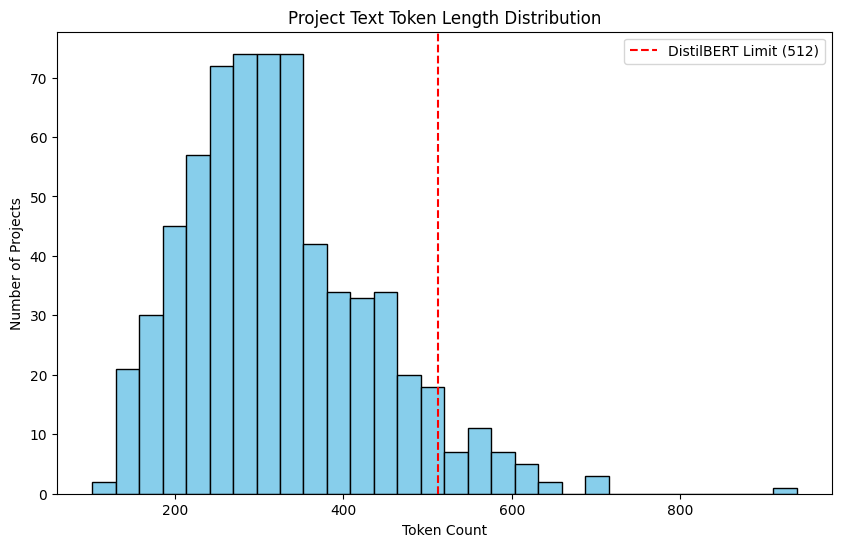

Ortalama token sayısı: 324.3813813813814
512 token'ı geçen proje sayısı: 41


In [ ]:
# Her projenin model tarafından kaç 'token' olarak algılandığını hesaplar
df['token_counts'] = df['combined_text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

# Token dağılımını görselleştirerek 512 sınırına yakınlığı kontrol eder
plt.figure(figsize=(10, 6))
plt.hist(df['token_counts'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=512, color='red', linestyle='--', label='DistilBERT Limit (512)')
plt.title('Project Text Token Length Distribution')
plt.xlabel('Token Count')
plt.ylabel('Number of Projects')
plt.legend()
plt.show()

# Veri kaybı olup olmadığını anlamak için özet istatistikler
print(f"Ortalama token sayısı: {df['token_counts'].mean()}")
print(f"512 token'ı geçen proje sayısı: {(df['token_counts'] > 512).sum()}")

In [ ]:
def mean_pooling(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """Attention mask'i dikkate alarak token embedding'lerinden mean pooling yapar."""
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)  # (B, T, 1)
    summed = (last_hidden_state * mask).sum(dim=1)                  # (B, H)
    counts = mask.sum(dim=1).clamp(min=1e-9)                        # (B, 1)
    return summed / counts


@torch.no_grad()
def get_embeddings(text):
    """
    Tek bir metin veya metin listesi için DistilBERT embedding üretir.
    - Token-level çıktılardan mean pooling ile cümle/doküman embedding'i elde edilir.
    Dönüş tipi: NumPy Array (float32)
    """
    single_input = isinstance(text, str)
    texts = [text] if single_input else list(text)

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)
    pooled = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])

    # (opsiyonel) cosine similarity için normalize etmek faydalı olur
    pooled = F.normalize(pooled, p=2, dim=1)

    emb = pooled.detach().cpu().numpy().astype(np.float32)
    return emb[0] if single_input else emb


# Pandas işlemlerine görsel ilerleme çubuğu (tqdm) ekler
tqdm.pandas()
print("🚀 DistilBERT embedding süreci başlatılıyor...")

# Tüm projeler için vektör üretir ve liste formatına çevirir
df["embedding"] = df["combined_text"].progress_apply(lambda x: get_embeddings(x).tolist())

print("\n✅ Embedding işlemi başarıyla tamamlandı.")
print(f"Toplam Kayıt: {len(df)}")
print(f"Vektör Boyutu: {len(df['embedding'].iloc[0])}")

🚀 DistilBERT embedding süreci başlatılıyor...


100%|██████████| 666/666 [00:04<00:00, 145.53it/s]


✅ Embedding işlemi başarıyla tamamlandı.
Toplam Kayıt: 666
Vektör Boyutu: 768


In [ ]:
df.head()


,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text,token_counts,embedding
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...,228,"[-0.012995732016861439, -0.03773871436715126, ..."
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,253,"[-0.02365931309759617, -0.02519919164478779, 0..."
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,251,"[-0.028615036979317665, -0.02731243707239628, ..."
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac...",158,"[-0.01512187160551548, -0.04927825182676315, 0..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,210,"[-0.004172096028923988, -0.03392811864614487, ..."


In [ ]:
def clean_text(text):
    # Metni temizleme
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[#%&*_=+<>]", "", text)
    return text.strip()

# Kullanıcıdan gelen ham veriler (Hiçbir kırpma yapılmamıştır)
raw_query_title = "Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi"

raw_query_abstract = (
    "Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak "
    "birebir muharebeler için otonom savunma algoritması geliştirilmiştir. "
    "Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda "
    "saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. "
    "Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan "
    "dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş "
    "manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı "
    "bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile "
    "algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir."
)

raw_query_keywords = "bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları."

# Metinleri birleştirme ve modele uygun vektöre çevirme
query_text = f"{clean_text(raw_query_title)} {clean_text(raw_query_abstract)} {clean_text(raw_query_keywords)}"
query_vector = get_embeddings(query_text)  # (H,)

# Mevcut veri kümesini karşılaştırma için hazırlama
corpus_embeddings = np.array(df["embedding"].tolist(), dtype=np.float32)  # (N, H)

# Kosinüs benzerliği hesaplama (embedding'ler normalize edildiği için dot-product yeterli)
similarity_scores = np.dot(corpus_embeddings, query_vector)

# Sonuçları raporlama ve benzerlik skoruna göre sıralama
df["similarity_score"] = similarity_scores
top_results = df.sort_values(by="similarity_score", ascending=False)

# En benzer ilk 5 sonuç
print("\n--- Anlamsal Arama Sonuçları ---")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].head(5))

print("\n", "*"*215)

# En az benzer son 5 sonuç
print("\n--- En Az Benzer Sonuçlar ---")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].tail(5))



--- Anlamsal Arama Sonuçları ---


,Year,Title_TR,Abstract_TR,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi,"Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir.",1.000000
186,2021-2022,Otonom Hava Muharebelerinde Bulanık Metodlar Kullanılarak Karar Verme Algoritmalarının Gerçeklenmesi ve Analizi,"Hava muharebelerinde otonominin giderek yaygın- laşmasıyla birlikte görevleri yüksek başarı oranlarıyla gerçekleş- tirecek uçuş algoritmalarının önemi her geçen gün artmaktadır. Bu çalışmada ise bulanık mantık destekli karar verme algoritma- ları ile otonom hava muharebelerinde meydana gelebilecek du- rumlar için bulanık mantık kural tabanı ile MATLAB kullanıla- rak uçuş senaryolarının simülasyon ortamında gerçeklenmesi amaçlanmıştır. Uçakların it dalaşındaki etkinliği değerlendiril- mektedir. Algoritma, hedef uçak hareketine bağlı olarak bulanık mantık kural tabanına göre uygun referans değerlerini üreterek saldırı manevraları gerçekleştirmektedir.",0.977036
165,2021-2022,Helikopter ile Hareketli Gemi Güvertesine Otonom Şekilde İniş,"Bu çalışmada, döner kanatlı hava araçlarına, otonom hareket kabiliyeti kazandırmak için gerekli olan seyrüsefer ve kontrol algoritmalarının geliştirilmesine odaklanılmıştır. Bahsedilen araçların dinamik modellerinin eldesi ise çalışmanın kapsamı ve hedefi dışında bırakılmıştır. Bu amaçla, seyrüsefer ve kontrol algoritmaları MATLAB / Simulink nümerik hesaplama programı kullanılarak oluşturulmuştur. Dinamik sistem modeli ise açık kaynak uçuş simülatörü olan FlightGear ortamında koşturulmuştur. Bu iki program, aralarında sağlanan veri transferi ile koordineli olarak çalıştırılmış ve benzetim sonuçları elde edilmiştir. Seyrüsefer kısmında, bulunulan nokta ile hedef noktaları doğru parçaları veya türevlenebilir eğriler ile birleştiren farklı düzergahlar tayin edilmiş, her iki yaklaşım için katedilen toplam mesafe, ortalama hız, maksimum hız gibi istatistiki veriler ile karşılaştırmalar yapılmıştır. Kontrol kısmında ise, ileri yönlü hız, yanal hız, dönüklük açısı ve irtifa değişkenlerini istenilen değerlerde tutan çok döngülü oransal (P) ve oransal-integral (PI) tipi kompansatörler oluşturulmuştur. Elde edilen algoritmalar, Atatürk Havalimanının 35L - 17R - 17L- 35R pistlerinin başlangıç ve bitiş noktalarının dolaşıldığı ve Marmara Denizinde seyir halinde olan muhrip sınıfı savaş gemisinin helikopter pistine iniş yapıldığı iki ayrı senaryo kullanılarak test edilmiştir.",0.971378
386,2023-2024,6 Serbestlik Dereceli Uçak Modeli ile Manevra Kontrolü,"Bu araştırma projesi, uçakların temel ve akrobatik manevralar sırasında kontrolü için kontrolcü tasarımı ve simülasyonunu kapsamaktadır. İlk olarak, altı serbestlik derecesinde hareket denklemleri kullanılarak bir uçak modeli oluşturulmuş ve MATLAB/Simulink programı kullanılarak aerodinamik, itki ve atmosfer kütüphaneleri entegre edilmiştir. Lineer olmayan denklemler lineerleştirilmiş, dinamik modlar elde edilmiş ve veriler FlightGear'da görselleştirilmiştir. Çalışma, SİHA tipi uçakların artan önemi doğrultusunda, akrobatik manevralar için gerekli olan kontrolcü ve manevra planlamasına odaklanmaktadır. Uçağın dinamik davranışını yönetebilen ve yüksek ivmeli manevraları gerçekleştirebilen kontrolcü seçilmiş ve entegre edilmiştir. Sonraki aşamalarda, bu kontrolcü optimize edilerek stabilite ve manevra kabiliyeti artırı


 ***********************************************************************************************************************************************************************************************************************

--- En Az Benzer Sonuçlar ---


,Year,Title_TR,Abstract_TR,similarity_score
269,2022-2023,Elektromanyetik Kalkanlama İçin Polimer Köpükler,"Elektromanyetik kalkanlama (EMI Shield), temelde faraday kafesi prensibine dayanmaktadır, elektrik elektronik mühendisliğinde “ekranlama“ olarak geçer ve elektromanyetik dalgaların soğrulma, yansıma ve saçılma sonucunda belirli alana girememesi veya yine belirli alandan dışarıya çıkamaması gibi amaçlar için kullanılır. Bu çalışmada Polifenilen sülfit (PPS) polimerine belirli oranlarda Mikro Cam Küre ve Grafen malzemeleri ekstrüzyon veya sıcak pres yöntemleri ile katkı yapılarak hibrit polimer kompozitler elde edilmiştir. Malzeme konsantrasyonun yanında üretim yöntemlerinin, kompozitlerin elektromanyetik geçirgenliği, elektriksel iletkenliği ve termal özelliklerine etkisi incelenmiştir.",0.892897
60,2020-2021,Ulusal Savunma Sanayiinde Lif Bazlı Kompozitlerin İncelenmesi,"Bu projede, savunma ve havacılık endüstrisinde kullanılmak üzere lif bazlı kompozit malzemeler için literatür araştırması yapılmıştır. Bu çalışmalar kapsamında braiding teknolojisi kullanılarak karbon lifi takviyeli boru şeklinde braided kompozit yapısı elde etmek amaçlanmıştır. Bu amaç doğrultusunda elde edilen kompozit malzeme yapısının özellikleri incelenmiştir.",0.890550
356,2022-2023,Sis Hadisesinin Uçuşa Etkisi ve İstanbul Uluslararası Havalimanı’nda Meydana Gelen Sis Hadiselerinin Analizi ve Tahmini,"Çalışmada, İstanbul Uluslararası Havalimanı (International Civil Aviation Organisation (ICAO) kodu: LTFM)’nın 2019-2021 yılları arasındaki 3 yıllık, İstanbul Atatürk Uluslararası Havalimanı (ICAO kodu: LTBA)’nın ve İstanbul Sabiha Gökçen Uluslararası Havalimanı (ICAO kodu: LTFJ)’nin ise 2012-2021 yılları arasındaki 10 yıllık meteorolojik verileri incelenerek sis analizi yapılmıştır. Analiz kısmından sonra ise LTFM’ye ait 4.5 yıllık veri ile korelasyon çalışması yaparak ve fog stability index (FOGSİ) indeksi hesaplanarak sis tahmini yapılmıştır. LTFM’de 3 yıllık periyotta 47 gün, LTBA’da 10 yıllık periyotta 36 gün, LTFJ’de 10 yıllık periyotta 200 gün sisli gün tespit edilmiştir. Yapılan tahmin çalışmasında ise fog stability index (FOGSİ)’in LTFM’deki sisi tahmin etmede başarısız olduğu sonucuna varılmıştır. LTFM’yi en iyi temsil edecek kendi sis kararlılık index çalışmamız devam etmektedir.",0.885349
641,2023-2024,Toz Yataklı Eklemeli İmalat Yöntemleri ile Üretilen AlSi10Mg Parçalarında Yüzey İşlemi Çalışmaları,"Bu çalışmada, toz yataklı eklemeli imalat yöntemleriyle üretilen AlSi10Mg parçalarının yüzey kalitesini iyileştirmek için Lazerli Parlatma (LP) ve Santrifüj Yüzey İşleme (SYİ) yöntemlerinin etkinliği deneysel olarak incelenmiştir. LP işlemi uygulanan parçalarda, başlangıçta 5.933 μm olan Ra yüzey pürüzlülük değeri 0.74 μm'ye düşmüş, SYİ işlemi uygulanan parçalarda ise bu değer 0.38 μm'ye kadar inmiştir. Her iki işlem de proje hedefleri doğrultusunda Ra değerini 1 μm'nin altına indirmeyi başarmıştır. Bu sonuçlar, hem LP hem de SYİ yöntemlerinin AlSi10Mg parçalarının yüzey kalitesini belirgin şekilde artırabildiğini göstermektedir.",0.881510
341,2022-2023,"Poliüretan Bazlı Hidrofilik, Saydam Kaplama Geliştirilmesi","Bu çalışmada polikarbonat üzerinde poliüretan bazlı, saydam, hidrofilik kaplama geliştirilmesi çalışılmıştır. Elimizde olan PUD, HDI, NMP ile kaplamanın özelliklerinin geliştirilmesi çalışılmıştır. Hidrofilikliği sağlamak için “korona plazma” yöntemi seçilerek temas açısının düşürülmesi denenmiştir.",0.877548


In [ ]:
df["combined_text"].iloc[2]


'hava muharebesinde otonom savunma algoritmasının geliştirilmesi bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. matlab/simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir. bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları.'

In [ ]:
df["embedding"].iloc[2]


[-0.028615036979317665,
 -0.02731243707239628,
 0.04137514531612396,
 0.022216131910681725,
 0.012375183403491974,
 0.043304506689310074,
 -0.0038653190713375807,
 0.0030101847369223833,
 -0.00927245058119297,
 0.03484625741839409,
 -0.026231952011585236,
 0.06745817512273788,
 0.010530841536819935,
 0.007494892925024033,
 0.012826764956116676,
 -0.03542594984173775,
 0.03731028363108635,
 0.03350968286395073,
 -0.061821721494197845,
 -0.003953773528337479,
 -0.05837222561240196,
 0.005875886417925358,
 -0.01346553023904562,
 0.02462773770093918,
 0.03156457841396332,
 0.06577137857675552,
 -0.05709700286388397,
 -0.009045133367180824,
 -0.008758415468037128,
 -0.014925035648047924,
 0.005314977373927832,
 0.040784209966659546,
 0.0008720448240637779,
 0.07712309062480927,
 -0.02469095215201378,
 -0.014383104629814625,
 -0.010342414490878582,
 0.015267441980540752,
 0.03380225598812103,
 -0.06646831333637238,
 0.008416874334216118,
 0.036420948803424835,
 -0.03818840533494949,
 -0.0053

In [ ]:
top_results.head()


,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text,token_counts,embedding,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,251,"[-0.028615036979317665, -0.02731243707239628, ...",1.000000
186,2021-2022,Otonom Hava Muharebelerinde Bulanık Metodlar K...,Hava muharebelerinde otonominin giderek yaygın...,"otonom hava muharebeleri, bulanık mantık, kara...",otonom hava muharebelerinde bulanık metodlar k...,hava muharebelerinde otonominin giderek yaygın...,"otonom hava muharebeleri, bulanık mantık, kara...",otonom hava muharebelerinde bulanık metodlar k...,242,"[-0.013904650695621967, -0.028056040406227112,...",0.977036
165,2021-2022,Helikopter ile Hareketli Gemi Güvertesine Oton...,"Bu çalışmada, döner kanatlı hava araçlarına, o...","Döner Kanatlı Hava Aracı, Helikopter; Otonom U...",helikopter ile hareketli gemi güvertesine oton...,"bu çalışmada, döner kanatlı hava araçlarına, o...","döner kanatlı hava aracı, helikopter; otonom u...",helikopter ile hareketli gemi güvertesine oton...,477,"[-0.012666071765124798, -0.02991405874490738, ...",0.971378
386,2023-2024,6 Serbestlik Dereceli Uçak Modeli ile Manevra ...,"Bu araştırma projesi, uçakların temel ve akrob...",uçak kontrolü; akrobatik manevralar; MATLAB/Si...,6 serbestlik dereceli uçak modeli ile manevra ...,"bu araştırma projesi, uçakların temel ve akrob...",uçak kontrolü; akrobatik manevralar; matlab/si...,6 serbestlik dereceli uçak modeli ile manevra ...,428,"[-0.017934264615178108, -0.03017721325159073, ...",0.970379
546,2023-2024,LEO (Low Earth Orbit) Uydular İçin Çarpışma An...,Çarpışma olasılığına karşı önlemler almak adın...,"LEO uyduları, Çarpışma önleme, Hedefleme algor...",leo (low earth orbit) uydular i̇çin çarpışma a...,çarpışma olasılığına karşı önlemler almak adın...,"leo uyduları, çarpışma önleme, hedefleme algor...",leo (low earth orbit) uydular i̇çin çarpışma a...,447,"[-0.022931575775146484, -0.03681480884552002, ...",0.969848
